# Exploratory Data Analysis - Understanding our Dataset

### Learning Objectives:
In this notebook we will use the following concepts in a practical setting:
 - Probability
 - Conditional probability
 - Distributions


# 1. Import the Python Libraries

As usual, the first thing we need to do is import the libraries that we will use in this notebook. `pandas` will help we load and manipulate data, while `matplotlib` will be used for plottting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load the Dataset

The next step is to load the dataset. The dataset has been downsampled by a factor of 100 to work smoothly in this environment. 

The dataset is a compilataion of all trips taken by taxis running in chicago

In [2]:
# Open the dataset
df = pd.read_csv("datasets/rideshare_2022.csv", parse_dates=['Trip Start Timestamp', 'Trip End Timestamp'])

# Show the first five rows of the dataset
df.head()

,Trip ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,...,Trip Total,Shared Trip Authorized,Trips Pooled,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location,len_date
0,04767642defd6a3825d089ae66183906a89b902d,2022-01-01,2022-01-01 01:15:00,3905.0,44.5,1.703104e+10,NaN,4.0,NaN,55.0,...,66.25,0,1,41.972563,-87.678846,POINT (-87.6788459662 41.9725625375),NaN,NaN,NaN,16
1,138de88e19e045d9962f1f669e668f9dcdfbc9fd,2022-01-01,2022-01-01 00:30:00,2299.0,25.0,NaN,NaN,32.0,NaN,32.5,...,46.68,0,1,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),NaN,NaN,NaN,16
2,249cb7bc8eea309aaa3ef941756df4f62a53a92a,2022-01-01,2022-01-01 00:00:00,275.0,1.5,NaN,NaN,40.0,38.0,7.5,...,8.52,0,1,41.792357,-87.617931,POINT (-87.6179313803 41.7923572233),41.812949,-87.617860,POINT (-87.6178596758 41.8129489392),16
3,36c8a2a4cd85fb32ae32170550d2a4d30b8df8a1,2022-01-01,2022-01-01 00:15:00,243.0,1.0,1.703106e+10,1.703106e+10,6.0,6.0,5.0,...,7.36,0,1,41.936310,-87.651563,POINT (-87.6515625922 41.9363101308),41.943155,-87.640698,POINT (-87.640698076 41.9431550855),16
4,493f7bbcba1d96bf10bd579fe1c4b7ddb95fd3a6,2022-01-01,2022-01-01 00:15:00,364.0,1.3,1.703107e+10,1.703106e+10,7.0,6.0,5.0,...,7.36,0,1,41.921855,-87.646211,POINT (-87.6462109769 41.9218549112),41.936237,-87.656412,POINT (-87.6564115308 41.9362371791),16


# 3 Explore the Dataset

In the cell above, we have opened the dataset and displayed the first five rows. Have a closer look at the output of the cell above. The dataset consists of the following columns:

- `Trip ID`: A unique identifier for the trip.


- `Trip Start Timestamp`: When the trip started, rounded to the nearest 15 minutes.


- `Trip End Timestamp`: When the trip ended, rounded to the nearest 15 minutes.


- `Trip Seconds`: Time of the trip in seconds.


- `Trip Miles`: Distance of the trip in miles.


- `Pickup Census Tract`: The Census Tract where the trip began. This column often will be blank for locations outside Chicago.


- `Dropoff Census Tract`: The Census Tract where the trip ended. This column often will be blank for locations outside Chicago.


- `Pickup Community Area`: The Community Area where the trip began. This column will be blank for locations outside Chicago.


- `Dropoff Community Area`: The Community Area where the trip ended. This column will be blank for locations outside Chicago.


- `Fare`: The fare for the trip, rounded to the nearest $2.50. 


- `Tip`: The tip for the trip, rounded to the nearest $1.00. Cash tips will not be recorded.


- `Additional Charges`: The taxes, fees, and any other charges for the trip.


- `Trip Total`: Total cost of the trip. This is calculated as the total of the previous columns, including rounding.


- `Shared Trip Authorized`: Whether the customer agreed to a shared trip with another customer, regardless of whether the customer was actually matched for a shared trip.


- `Trips Pooled`: If customers we re matched for a shared trip, how many trips, including this one, we re pooled. All customer trips from the time the vehicle was empty until it was empty again contribute to this count, even if some customers we re never present in the vehicle at the same time. Each trip making up the overall shared trip will have a separate record in this dataset, with the same value in this column.


- `Pickup Centroid Latitude`: The latitude of the center of the pickup census tract or the community area if the census tract has been hidden for privacy. This column often will be blank for locations outside Chicago.


- `Pickup Centroid Longitude`: The longitude of the center of the pickup census tract or the community area if the census tract has been hidden for privacy. This column often will be blank for locations outside Chicago.


- `Pickup Centroid Location`: The location of the center of the pickup census tract or the community area if the census tract has been hidden for privacy. This column often will be blank for locations outside Chicago.


- `Dropoff Centroid Latitude`: The latitude of the center of the dropoff census tract or the community area if the census tract has been hidden for privacy. This column often will be blank for locations outside Chicago.


- `Dropoff Centroid Longitude`: The longitude of the center of the dropoff census tract or the community area if the census tract has been hidden for privacy. This column often will be blank for locations outside Chicago.


- `Dropoff Centroid Location`: The location of the center of the dropoff census tract or the community area if the census tract has been hidden for privacy. This column often will be blank for locations outside Chicago.


Run the cell below to print out the column names and inspect the number of non-null values and the data type of each column. 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 691098 entries, 0 to 691097
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Trip ID                     691098 non-null  str           
 1   Trip Start Timestamp        691098 non-null  datetime64[us]
 2   Trip End Timestamp          691098 non-null  datetime64[us]
 3   Trip Seconds                691073 non-null  float64       
 4   Trip Miles                  691096 non-null  float64       
 5   Pickup Census Tract         398943 non-null  float64       
 6   Dropoff Census Tract        397574 non-null  float64       
 7   Pickup Community Area       633092 non-null  float64       
 8   Dropoff Community Area      630431 non-null  float64       
 9   Fare                        689952 non-null  float64       
 10  Tip                         689952 non-null  float64       
 11  Additional Charges          689952 non-null  float

## 3.1 Select columns of interest

At this point, we have seen what the dataset looks like. Take a moment to think of our next steps. Which columns would we explore further? Is there a column that has a problematic number of null values? Are there any columns that we are not interested in?

For exploratory data analysis it is perfectly fine to select only the columns that we are interested in and drop the remainder. This will not only make our dataframe easier to work with, but also reduce its size, making our operations faster.

In the cell below we will select a subset of the columns, which are the ones we will be interested in for this notebook. If we keep only the columns that are pre-selected in the cell below, we will reduce the file size by about a half. This can make a difference of whether we can fit the file into the memory or not, especially with larger files. This code will also rename the columns to remove white spaces.

In [5]:
columns_of_interest = ['Trip Start Timestamp', 'Trip Seconds',
       'Trip Miles', 'Fare', 'Tip', 'Additional Charges', 'Trip Total', 'Shared Trip Authorized',
       'Trips Pooled', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude', 'Dropoff Centroid Latitude',
       'Dropoff Centroid Longitude']

df = df[columns_of_interest]

# Rename all the columns to not include whitespace
df = df.rename(columns={i: "_".join(i.split(" ")).lower() for i in df.columns})

# Check the info on the cleaned-up dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 691098 entries, 0 to 691097
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   trip_start_timestamp        691098 non-null  datetime64[us]
 1   trip_seconds                691073 non-null  float64       
 2   trip_miles                  691096 non-null  float64       
 3   fare                        689952 non-null  float64       
 4   tip                         689952 non-null  float64       
 5   additional_charges          689952 non-null  float64       
 6   trip_total                  689952 non-null  float64       
 7   shared_trip_authorized      691098 non-null  int64         
 8   trips_pooled                691098 non-null  int64         
 9   pickup_centroid_latitude    635075 non-null  float64       
 10  pickup_centroid_longitude   635075 non-null  float64       
 11  dropoff_centroid_latitude   632163 non-null  float

# 4. Visualize the data

To understand the data better, it often makes sense to visualize it. This helps we understand how the data is distributed. we can start by plotting the number of rides in a given day. For this it would be useful to have another column that just contains the date. The code in the cell below will create a new column which takes the `trip_start_timestamp` and converts it into a date.

In [6]:
df['date'] = pd.to_datetime(df['trip_start_timestamp'].dt.date)

df.head()

,trip_start_timestamp,trip_seconds,trip_miles,fare,tip,additional_charges,trip_total,shared_trip_authorized,trips_pooled,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,date
0,2022-01-01,3905.0,44.5,55.0,0.0,11.25,66.25,0,1,41.972563,-87.678846,NaN,NaN,2022-01-01
1,2022-01-01,2299.0,25.0,32.5,7.0,7.18,46.68,0,1,41.878866,-87.625192,NaN,NaN,2022-01-01
2,2022-01-01,275.0,1.5,7.5,0.0,1.02,8.52,0,1,41.792357,-87.617931,41.812949,-87.617860,2022-01-01
3,2022-01-01,243.0,1.0,5.0,0.0,2.36,7.36,0,1,41.936310,-87.651563,41.943155,-87.640698,2022-01-01
4,2022-01-01,364.0,1.3,5.0,0.0,2.36,7.36,0,1,41.921855,-87.646211,41.936237,-87.656412,2022-01-01


array([[<Axes: title={'center': 'date'}>]], dtype=object)

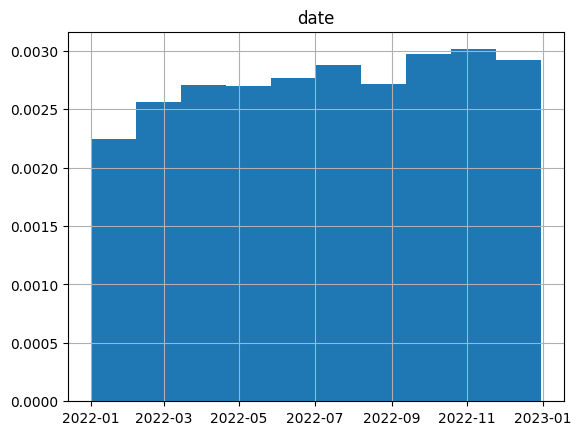

In [7]:
# Select the column which we want to plot.
column_to_plot = 'date'

# Plot the histogram of the desired column
df.hist(column_to_plot, density=True)

What we have plotted above is the distribution of the rides throughout the year. Note the code above also set the `dentsity=True`. This is so that the histogram is scaled to look like a probability density function like the ones we saw on theory notes. This means scaling the plot so that the area of the bars equals 1. What does this distribution look like to you? Is it similar to any of the distributions we saw in the notes?

In notes we understood,

$$
\begin{align}
Probability, P&=width*height \\
\text{Probability is calculated with,} \\
P&=\frac{\text{no. of samples in dataset in a given interval}}{\text{total no. of data in dataset}} \\
\text{Height and width of bin must be,} \\
\text{our interval is 2 months so width = 2} \\
\text{So,} \\
P&=H*W \\
P&=H*2 \\
H&=\frac{P}{2}
\end{align}
$$

Although the distribution is slightly smaller for earlier dates, we could probably say that the rides are quite uniformly distributed throughout the year. Just note that this is not the actual distribution of the dates of cab rides, but rather an estimate based on the observations we have. Since this is real-world data, there are some fluctuations.

Now change the `column_to_plot` variable above to some other column name to observe the distributions of other variables. Some interesting ones might be `fare`, `tip` or `trip_length`. These variables can tell us how far drivers have to drive and how much they are getting paid for it.

Lets look together at the `tip` column.

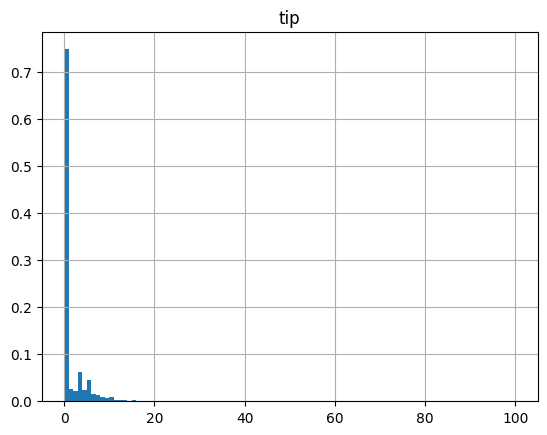

In [8]:
# Select the column which we want to plot.
column_to_plot = 'tip'

# Plot the histogram of the desired column
df.hist(column_to_plot, density=True, bins = 100);

What can we say about the distribution of tips? This one looks a bit weird, right? What could explain this strange distribution? What do we think the large bar on the left corresponds to?

What is actually happening here is that the majority of the people do not tip, and that's why we see a large bar at tip = 0. 

Based on the data, we can calculate the probability of the customer tipping. we can do this by simply calculating the proportion of customers that actually tipped from the total number of rides.

In [9]:
# Create a boolean series that distinguishes betwe en tippers and no-tippers
tippers = df['tip'] > 0
# Count the number of tippers
number_of_tippers = tippers.sum()
# Count the total number of rides
total_rides = len(df)

# Calculate the fraction of people who tip
fraction_of_tippers = number_of_tippers / total_rides
print(f'The percentage of riders who tip is {fraction_of_tippers*100:.0f}%.')

The percentage of riders who tip is 25%.


In the next cell we will create a new dataframe, where we will remove the non-tippers (the ones who gave a tip of zero). Then we can replot the histogram and see how it looks without the large bar at tip = 0.

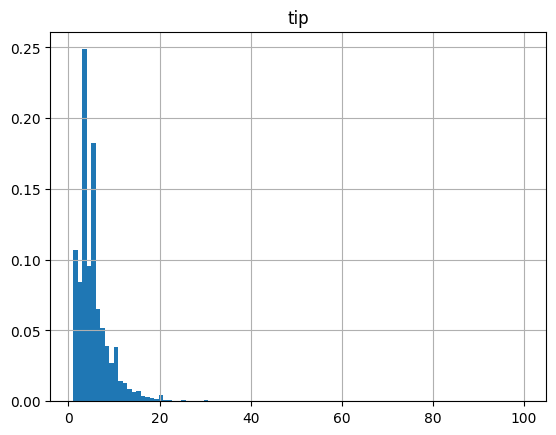

In [10]:
# Create a dataframe That only consists of tippers (conditioned on the boolean series)
df_tippers = df[tippers]

# Now re-plot the above histogram, but only for tippers
df_tippers.hist('tip', density=True, bins = 100);

we can see now that the distribution got a much more interesting shape. What we are actually doing here is conditioning the original variable `tip`. we are ploting the distribution of tips given that a tip was actually given, or given that `tip>0` if we want it in mathematical terms. In other words, we are discarding part of our data, where `tip=0`, and finding the distribution of the remaining data.

# 5. Split the Data Into Interesting Subsets

The next thing we can check is if we can create any subsets of data and have a look at conditional distributions over these subsets. For example, we might be interested, to know whether there are more rides on the weekend than during the week, or if people tip more on weekends. This can help we figure out whether there are any differences in demand during the week and helps us adjust the supply of drivers.

For this we will first create a new column called `weekday`, where we will store the information on the day of the week.

In [13]:
# Extracting the day of the we ek is simple when we have it in datetime format.
df['weekday'] = df["date"].dt.day_name()
df.head()

,trip_start_timestamp,trip_seconds,trip_miles,fare,tip,additional_charges,trip_total,shared_trip_authorized,trips_pooled,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,date,weekday
0,2022-01-01,3905.0,44.5,55.0,0.0,11.25,66.25,0,1,41.972563,-87.678846,NaN,NaN,2022-01-01,Saturday
1,2022-01-01,2299.0,25.0,32.5,7.0,7.18,46.68,0,1,41.878866,-87.625192,NaN,NaN,2022-01-01,Saturday
2,2022-01-01,275.0,1.5,7.5,0.0,1.02,8.52,0,1,41.792357,-87.617931,41.812949,-87.617860,2022-01-01,Saturday
3,2022-01-01,243.0,1.0,5.0,0.0,2.36,7.36,0,1,41.936310,-87.651563,41.943155,-87.640698,2022-01-01,Saturday
4,2022-01-01,364.0,1.3,5.0,0.0,2.36,7.36,0,1,41.921855,-87.646211,41.936237,-87.656412,2022-01-01,Saturday


Now we can count the number of riders on a given day of the week.

In [15]:
# Count the number of rides each day
daily_ride_counts = df['weekday'].value_counts()
# List of weekdays. we will use it to reorder the counts, as they are in random order.
WEEKDAYS = ['Monday', 'Tuesday', 'wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reorder the series given we ekdays
daily_ride_counts = daily_ride_counts.reindex(WEEKDAYS)

daily_ride_counts

weekday
Monday        79013.0
Tuesday       82576.0
wednesday         NaN
Thursday      95721.0
Friday       115923.0
Saturday     132872.0
Sunday        96959.0
Name: count, dtype: float64

And in the same manner, we will calculate the number of tippers on a given day of the we ek.

In [17]:
df_tippers = df[df['tip'] > 0]
# Count the number of tips given each day
daily_tippers_counts = df_tippers['weekday'].value_counts()
# Reorder the series given weekdays
daily_tippers_counts = daily_tippers_counts.reindex(WEEKDAYS)

daily_tippers_counts

weekday
Monday       19779.0
Tuesday      20898.0
wednesday        NaN
Thursday     24210.0
Friday       29256.0
Saturday     33215.0
Sunday       23294.0
Name: count, dtype: float64

Now we can calculate the percentage of customers tipping on each day of the week.

In [18]:
df_daily_aggregation = pd.concat([daily_ride_counts, daily_tippers_counts], axis=1, keys=['ride_count', 'tippers_count'])
df_daily_aggregation["tips_percentage"] = df_daily_aggregation['tippers_count'] / df_daily_aggregation['ride_count'] * 100

df_daily_aggregation

,ride_count,tippers_count,tips_percentage
weekday,,,
Monday,79013.0,19779.0,25.032590
Tuesday,82576.0,20898.0,25.307595
wednesday,NaN,NaN,NaN
Thursday,95721.0,24210.0,25.292256
Friday,115923.0,29256.0,25.237442
Saturday,132872.0,33215.0,24.997742
Sunday,96959.0,23294.0,24.024588


What we have just calculated are conditional probabilities: What is the probability of someone tipping, given a certain day of the week? Or if we write it with an equation: $ P(tip|weekday) $.
Now we can have another look at the numbers and see if there are some important insights!

we can see that there are significantly more rides on Fridays and Saturdays than on the other days of the week, however the percentage of the tippers does not change much.

we can use the cell below to save our modified dataframe.

In [ ]:
# Uncomment the line below if we want to save our dataframe.
# df.to_csv("data/rideshare_2022_user.csv", index=False)